# Exploratory Data Analysis (EDA)

## Objective

The purpose of this notebook is to explore the cleaned healthcare dataset, understand the distribution of variables, identify relationships between features, detect potential outliers, and uncover patterns that may influence hospital readmission.

The insights gained from this analysis will guide feature engineering and model development in the following stages.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**1. Load Clean Dataset**

In [2]:
df = pd.read_csv("../data/processed/clean_data.csv")
df

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),6,25,1,1,41,0,1,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,AfricanAmerican,Male,[70-80),1,3,7,3,51,0,16,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,AfricanAmerican,Female,[80-90),1,4,5,5,33,3,18,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,Caucasian,Male,[70-80),1,1,7,1,53,0,9,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,Caucasian,Female,[80-90),2,3,7,10,45,2,21,...,No,Up,No,No,No,No,No,Ch,Yes,NO


**2.Univariate Analysis**

In [18]:
categorical_features = df.select_dtypes(include="object").columns.tolist()

numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_features.remove("readmitted")

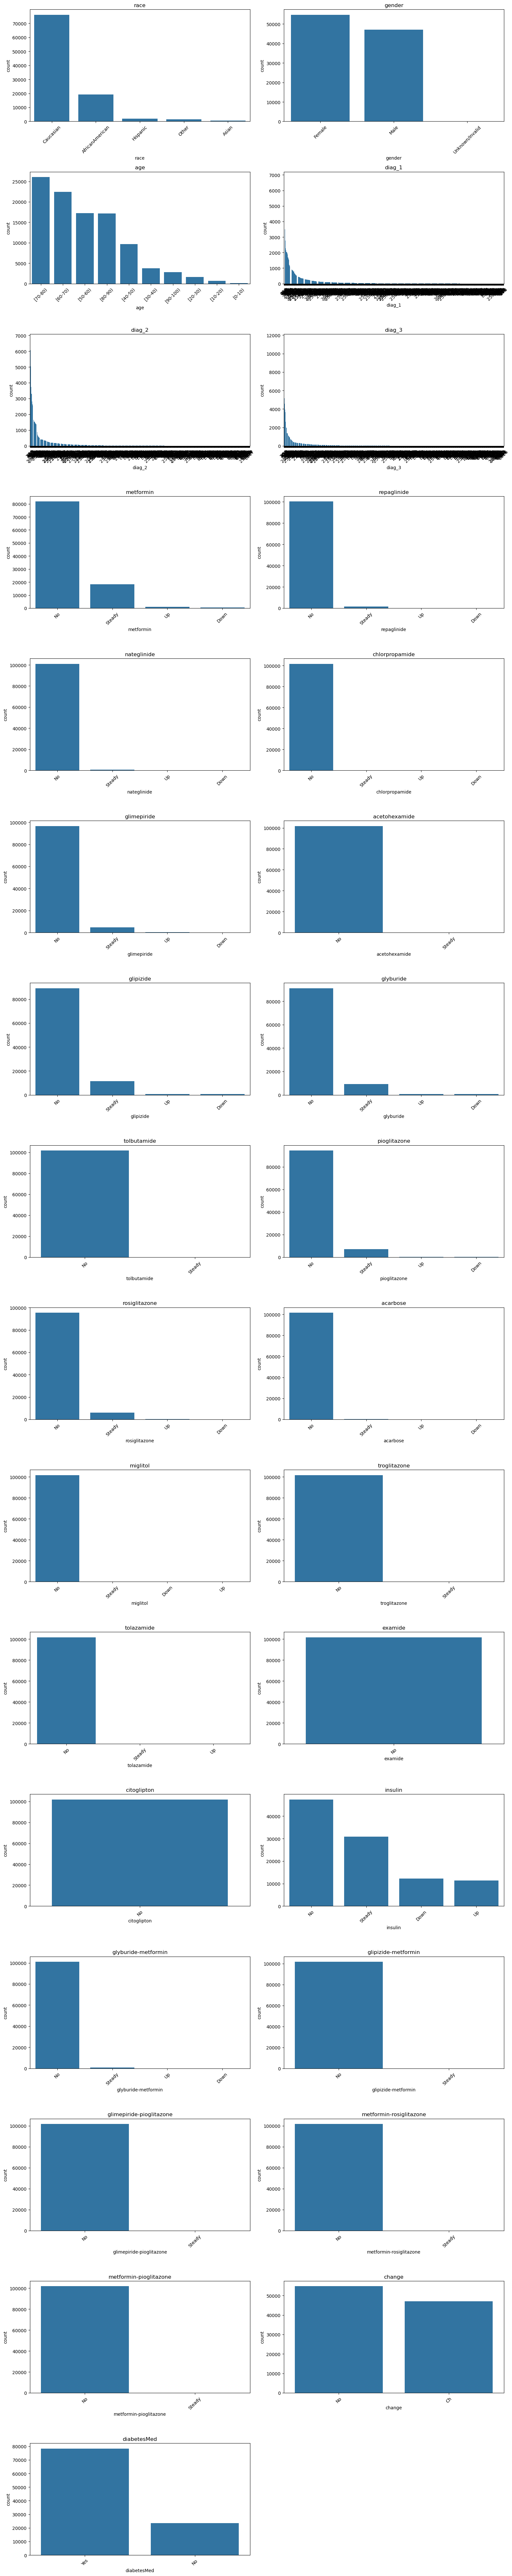

In [19]:
import math

n_cols = 2
n_rows = math.ceil(len(categorical_features) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 5*n_rows)
)

axes = axes.flatten()

for ax, feature in zip(axes, categorical_features):

    sns.countplot(
        data=df,
        x=feature,
        ax=ax,
        order=df[feature].value_counts().index
    )

    ax.set_title(feature)

    ax.tick_params(axis='x', rotation=45)

for ax in axes[len(categorical_features):]:
    fig.delaxes(ax)

plt.tight_layout()

plt.show()

**3.Target Analysis**

*for category feature*

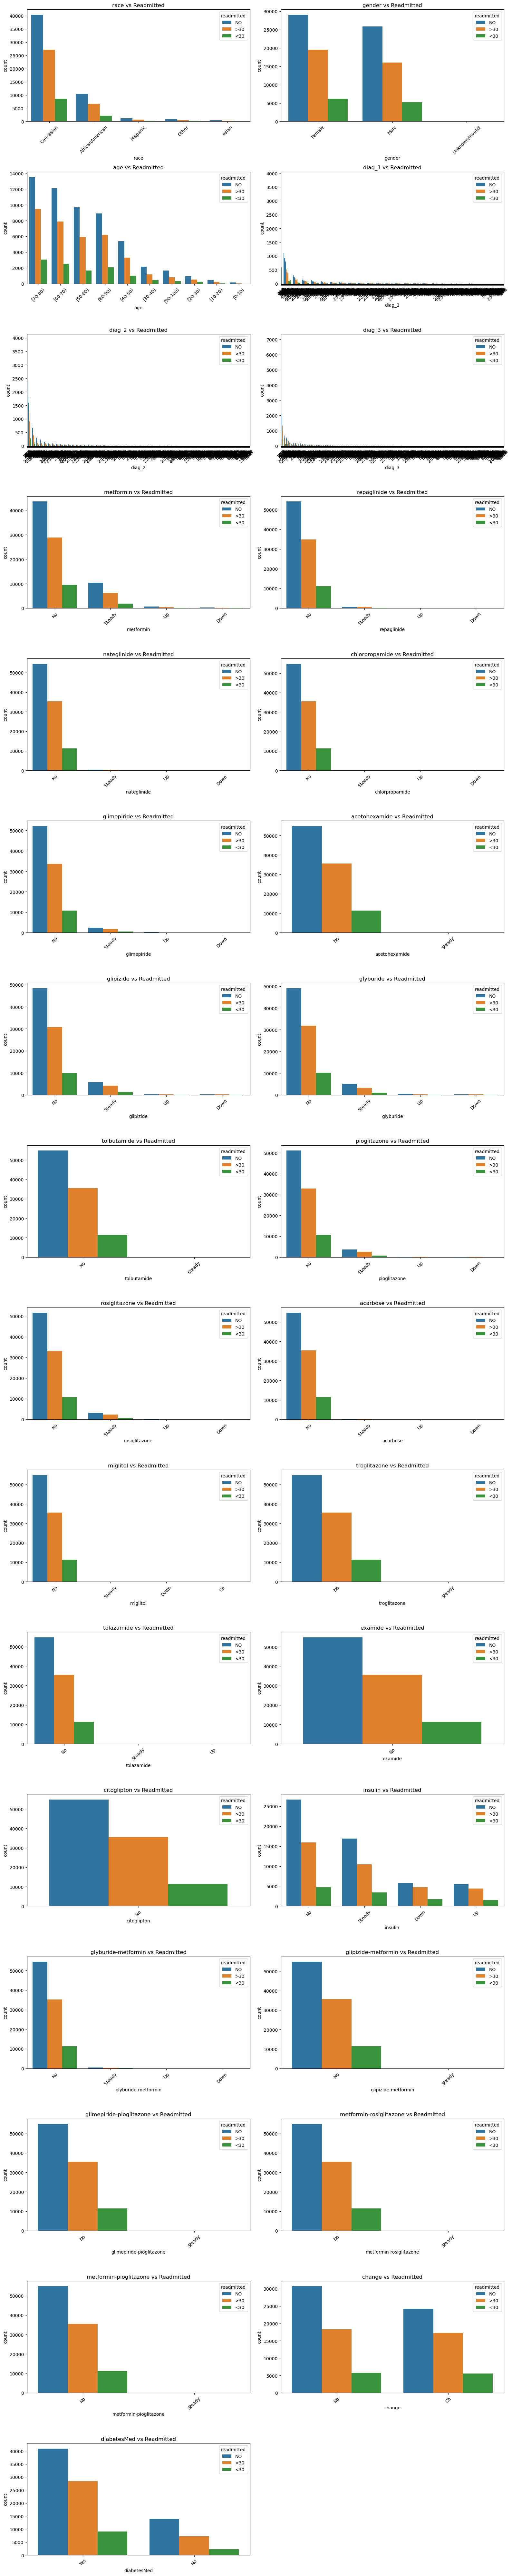

In [20]:
n_cols = 2
n_rows = math.ceil(len(categorical_features) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 5*n_rows)
)

axes = axes.flatten()

for ax, feature in zip(axes, categorical_features):

    sns.countplot(
        data=df,
        x=feature,
        hue="readmitted",
        ax=ax,
        order=df[feature].value_counts().index
    )

    ax.set_title(f"{feature} vs Readmitted")

    ax.tick_params(axis='x', rotation=45)

for ax in axes[len(categorical_features):]:
    fig.delaxes(ax)

plt.tight_layout()

plt.show()

*for numerical feature*

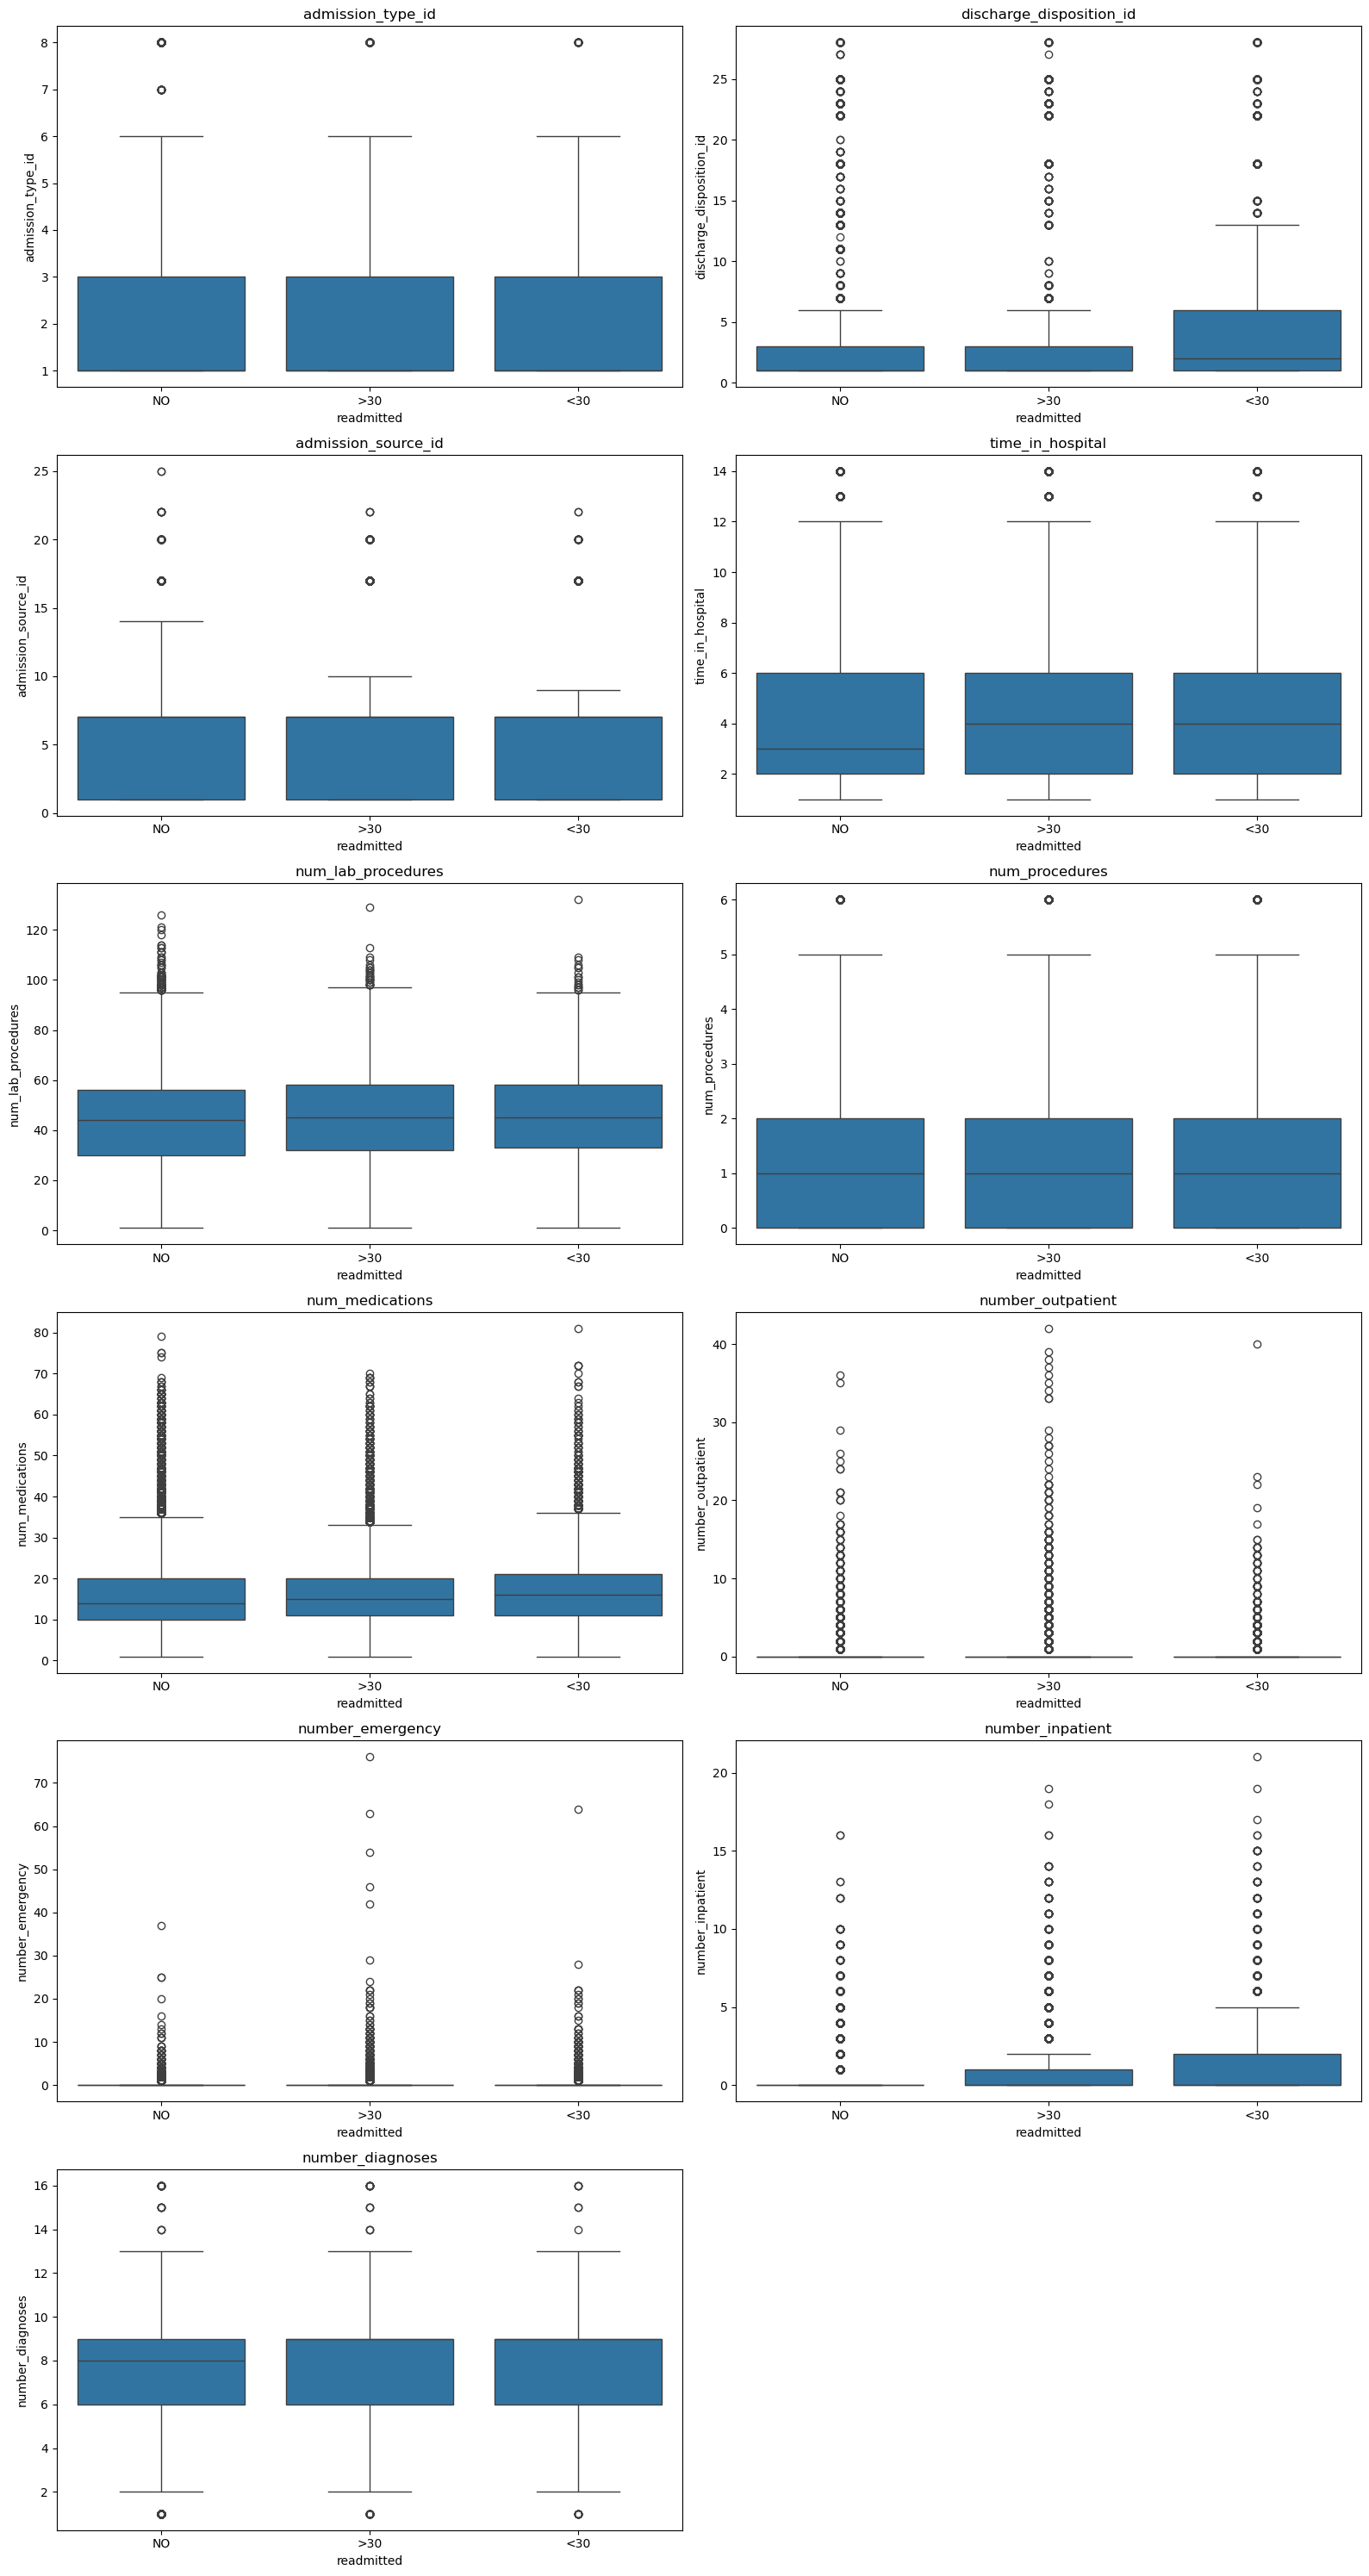

In [21]:
n_cols = 2
n_rows = math.ceil(len(numerical_features) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 5*n_rows)
)

axes = axes.flatten()

for ax, feature in zip(axes, numerical_features):

    sns.boxplot(
        data=df,
        x="readmitted",
        y=feature,
        ax=ax
    )

    ax.set_title(f"{feature}")

for ax in axes[len(numerical_features):]:
    fig.delaxes(ax)

plt.tight_layout()

plt.show()

**4.Correlation**

In [10]:
numeric = df.select_dtypes(include="number")

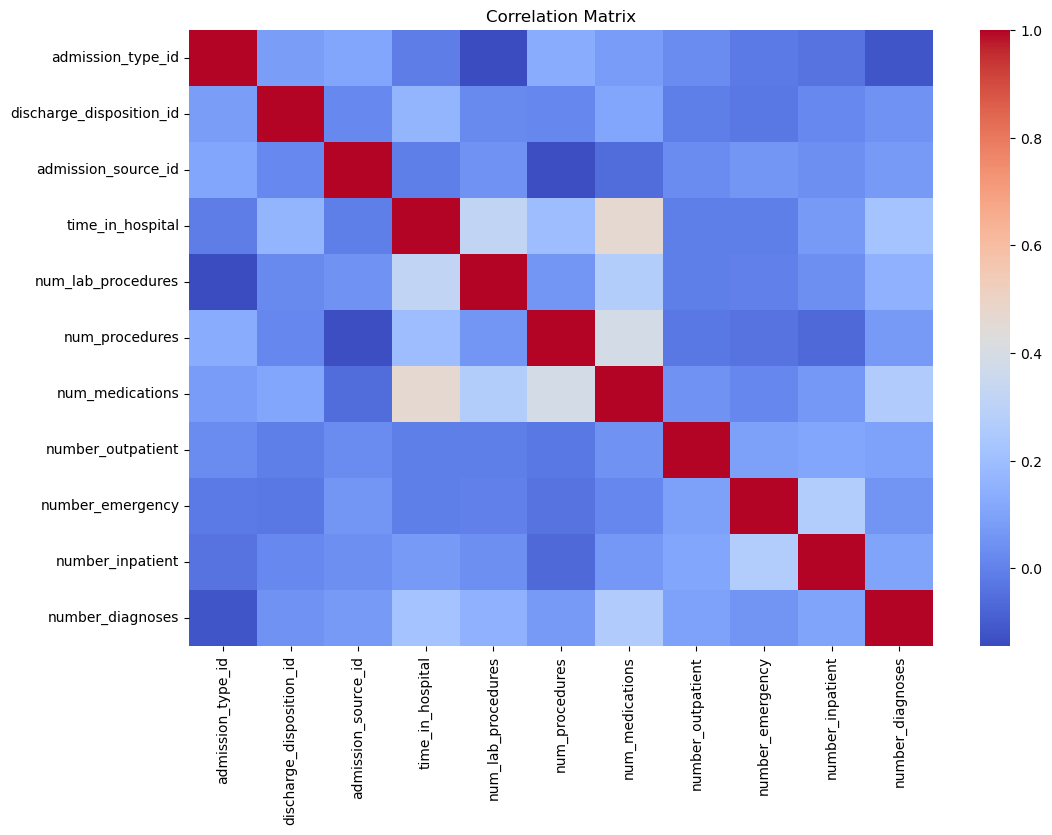

In [11]:
plt.figure(figsize=(12,8))

sns.heatmap(
    numeric.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Matrix")

plt.show()

**5.Outlier Investigation**

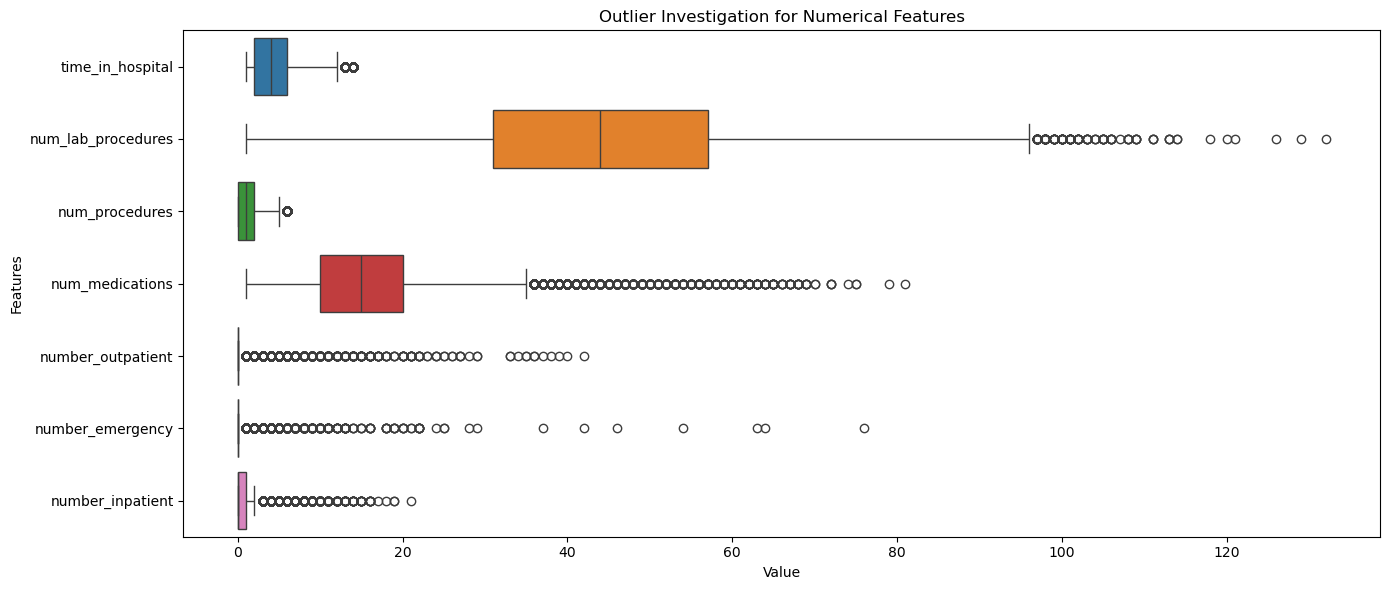

In [15]:
numeric_features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient"
]

plt.figure(figsize=(14,6))

sns.boxplot(
    data=df[numeric_features],
    orient="h"
)

plt.title("Outlier Investigation for Numerical Features")
plt.xlabel("Value")
plt.ylabel("Features")

plt.tight_layout()

plt.show()

## Key Findings

- Most patients are older adults.
- The dataset is dominated by patients aged between 60 and 80 years.
- Readmission appears to vary across age groups.
- Several numerical features exhibit right-skewed distributions.
- Some numerical variables contain extreme values that require further investigation.
- Correlation among numerical variables is generally low to moderate.

# Summary

In this notebook, exploratory data analysis was performed on the cleaned healthcare dataset.

The analysis provided valuable insights into feature distributions, relationships with the target variable, and potential data quality issues.

These findings will be used in the next stage to engineer informative features and improve predictive model performance.